#**Exploring Global GDP per Capita**
##An exploratory analysis of GDP per capita estimates from the IMF, United Nations and World Bank, investigating data quality, statistical distributions, regional differences and extreme values.
##Python · Pandas · Matplotlib · Seaborn

In [1]:
#uploanding dataset
from google.colab import files
uploaded = files.upload()

Saving GDP (nominal) per Capita.csv to GDP (nominal) per Capita.csv


In [2]:
#importing libraries and reading the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GDP (nominal) per Capita.csv",encoding= 'unicode_escape',  index_col=0)


##1. Exploring and preparing the Data

In [3]:
df.head(10)

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
1,Monaco,Europe,0,0,234316,2021,234317,2021
2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
4,Ireland,Europe,114581,2023,100172,2021,101109,2021
5,Bermuda,Americas,0,0,114090,2021,112653,2021
6,Norway,Europe,101103,2023,89154,2021,89242,2021
7,Switzerland,Europe,98767,2023,91992,2021,93525,2021
8,Singapore,Asia,91100,2023,72794,2021,66822,2021
9,Isle of Man,Europe,0,0,87158,2019,0,0
10,Cayman Islands,Americas,0,0,86569,2021,85250,2021


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 1 to 223
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country/Territory   223 non-null    object
 1   UN_Region           223 non-null    object
 2   IMF_Estimate        223 non-null    int64 
 3   IMF_Year            223 non-null    int64 
 4   WorldBank_Estimate  223 non-null    int64 
 5   WorldBank_Year      223 non-null    int64 
 6   UN_Estimate         223 non-null    int64 
 7   UN_Year             223 non-null    object
dtypes: int64(5), object(3)
memory usage: 15.7+ KB


In [5]:
df['IMF_Year'].dtype

dtype('int64')

In [6]:
df['IMF_Year'].unique()


array([   0, 2023, 2020, 2022])

In [7]:
df['IMF_Year'].value_counts()


,count
IMF_Year,
2023,193
0,26
2020,2
2022,2


In [8]:
df['WorldBank_Year'].unique()


array([2021, 2020, 2019, 2007,    0, 2018, 2014, 2011, 2015])

In [9]:
df['WorldBank_Year'].dtype


dtype('int64')

In [10]:
df['WorldBank_Year'].value_counts()


,count
WorldBank_Year,
2021,199
2020,7
0,7
2019,3
2018,2
2014,2
2007,1
2011,1
2015,1


In [11]:
df['UN_Year'].unique()


array(['2021', '0', '[n 10]2021'], dtype=object)

In [12]:
df['UN_Year'].value_counts()


,count
UN_Year,
2021,213
0,9
[n 10]2021,1


  After checking how many entries were available for each year and each organisation, as well as the data types of the year columns, I decided on the next steps to prepare the dataset for further analysis:

**1.** Clean the UN_Year column by converting "[n 10] 2021" to 2021.

**2.** Create a new DataFrame containing only the year with the highest coverage for each organisation.

  Based on the number of available entries, I selected:

  **IMF 2023**: representing 97% of its entries

  **UN 2021**: representing 95% of its entries
  
  **World Bank**: 2021, representing 89% of its entries

In [13]:
# Convert UN_Year to string so we can remove '[n 10]'
df['UN_Year'] = df['UN_Year'].astype(str).str.replace('[n 10]', '', regex=False)
df['UN_Year'].value_counts()

,count
UN_Year,
2021,214
0,9


In [14]:
#convert UN_Year to integer
df['UN_Year'] = df['UN_Year'].astype('Int64')
df['UN_Year'].dtype

Int64Dtype()

In [15]:
df_filtered = df[
    (df['WorldBank_Year'] == 2021) &
    (df['UN_Year'] == 2021) &
    (df['IMF_Year'] == 2023)
]
df_filtered.head()

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
4,Ireland,Europe,114581,2023,100172,2021,101109,2021
6,Norway,Europe,101103,2023,89154,2021,89242,2021
7,Switzerland,Europe,98767,2023,91992,2021,93525,2021
8,Singapore,Asia,91100,2023,72794,2021,66822,2021


In [16]:
df_filtered = df_filtered[
    (df_filtered['UN_Region'] != 'World') &
    (~df_filtered['Country/Territory'].str.startswith('European Union', na=False))
].copy()

##2. Choosing the Right Statistic

In [17]:
# Checking some summary statistics for World Bank estimates
df_filtered['WorldBank_Estimate'].agg(
    ['min', 'max', 'median', 'mean']).round(2)

,WorldBank_Estimate
min,222.00
max,133590.00
median,6228.00
mean,15926.84


In [18]:
# Count how many countries are above the median
print(df_filtered[df_filtered['WorldBank_Estimate'] > 6228.00]['Country/Territory'].count())

91


In [19]:
# Count how many countries are below the median
print(df_filtered[df_filtered['WorldBank_Estimate'] < 6228.00]['Country/Territory'].count())

91


In [20]:
# Count how many countries are above the mean
print(df_filtered[df_filtered['WorldBank_Estimate'] > 15926.84]['Country/Territory'].count())

54


In [21]:
# Count how many countries are bellow the mean
print(df_filtered[df_filtered['WorldBank_Estimate'] < 15926.84]['Country/Territory'].count())


129


The code above shows how the distribution of GDP per capita across countries looks different depending on whether we use the mean or the median. Because of the large differences between the richest and poorest countries, a small number of very high values pull the mean upwards. As a result, many more countries fall below the mean than above it. For this reason, I will use the median as the main measure of central tendency in the following analysis.

In [22]:
# Checking some summary statistics for IMF estimates
df_filtered['IMF_Estimate'].agg(
    ['min', 'max', 'median', 'mean']).round(2)

,IMF_Estimate
min,249.00
max,132372.00
median,7017.00
mean,17605.75


In [23]:
# Checking some summary statistics for UN estimates
df_filtered['UN_Estimate'].agg(
    ['min', 'max', 'median', 'mean']).round(2)

,UN_Estimate
min,311.00
max,133745.00
median,6229.00
mean,15929.19


In [24]:
# Median for all three international organisations
df_filtered[['WorldBank_Estimate', 'IMF_Estimate', 'UN_Estimate']].median()


,0
WorldBank_Estimate,6228.0
IMF_Estimate,7017.0
UN_Estimate,6229.0


##2.1 Countries Below and Above the Median

In [25]:
#countries above median for WorldBank_Estimates
df_filtered[df_filtered['WorldBank_Estimate'] > 6357.00][['Country/Territory', 'WorldBank_Estimate']]

,Country/Territory,WorldBank_Estimate
3,Luxembourg,133590
4,Ireland,100172
6,Norway,89154
7,Switzerland,91992
8,Singapore,72794
...,...,...
116,Peru,6622
118,North Macedonia,6695
119,Botswana,6805
120,Albania,6493


In [26]:
##countries below median for WorldBank_Estimates
df_filtered[df_filtered['WorldBank_Estimate'] < 6357.00][['Country/Territory', 'WorldBank_Estimate']]


,Country/Territory,WorldBank_Estimate
114,Armenia,4967
117,Georgia,5023
121,Belize,6228
123,Azerbaijan,5388
124,Ecuador,5965
...,...,...
217,Madagascar,501
218,Central African Republic,461
219,Malawi,635
221,Sierra Leone,480


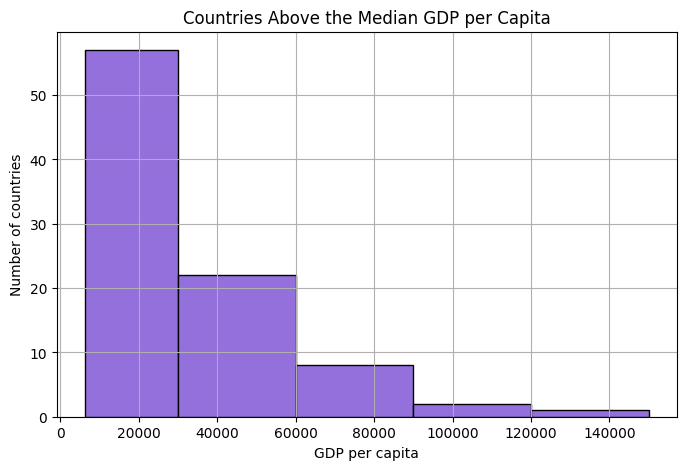

In [27]:
# histogram of countries above median
df_filtered[df_filtered['WorldBank_Estimate'] > 6357.00]['WorldBank_Estimate'].hist(
    bins=[6357, 30000, 60000, 90000, 120000, 150000],
    figsize=(8, 5),
    color='mediumpurple',
    edgecolor='black'
)

plt.xlabel('GDP per capita')
plt.ylabel('Number of countries')
plt.title('Countries Above the Median GDP per Capita')

plt.show()


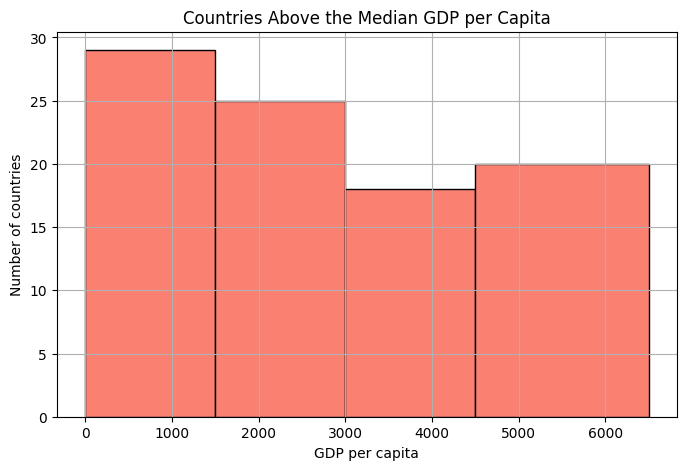

In [28]:
# histogram of countries bellow median

df_filtered[df_filtered['WorldBank_Estimate'] < 6357.00]['WorldBank_Estimate'].hist(
    bins=[0, 1500, 3000, 4500, 6500],
    figsize=(8, 5),
    color='salmon',
    edgecolor='black'
)

plt.xlabel('GDP per capita')
plt.ylabel('Number of countries')
plt.title('Countries Above the Median GDP per Capita')

plt.show()


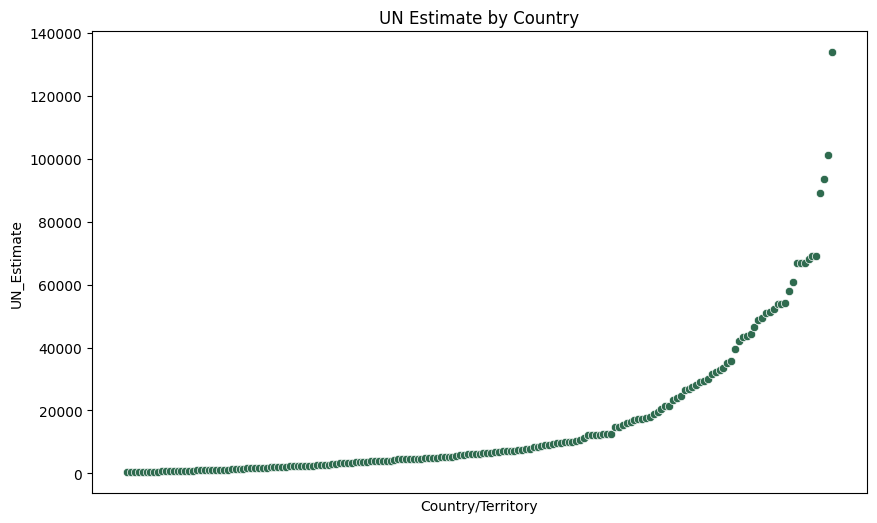

In [29]:
# scatterplot with all countries
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered.sort_values('UN_Estimate', ascending = True),
    x='Country/Territory',
    y='UN_Estimate',
    color = '#2F6B4F'
)

plt.xticks([])
plt.title("UN Estimate by Country")


plt.show()

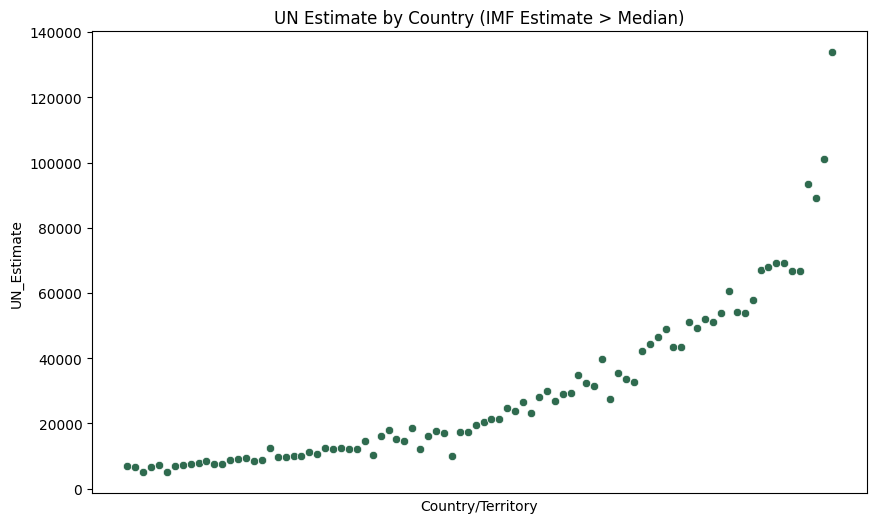

In [30]:
# Scatterplot for countries above median

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered[df_filtered['IMF_Estimate'] > 7058.00].sort_values('IMF_Estimate'),
    x='Country/Territory',
    y='UN_Estimate',
    color = '#2F6B4F'
)

plt.xticks([])
plt.title("UN Estimate by Country (IMF Estimate > Median)")
plt.show()

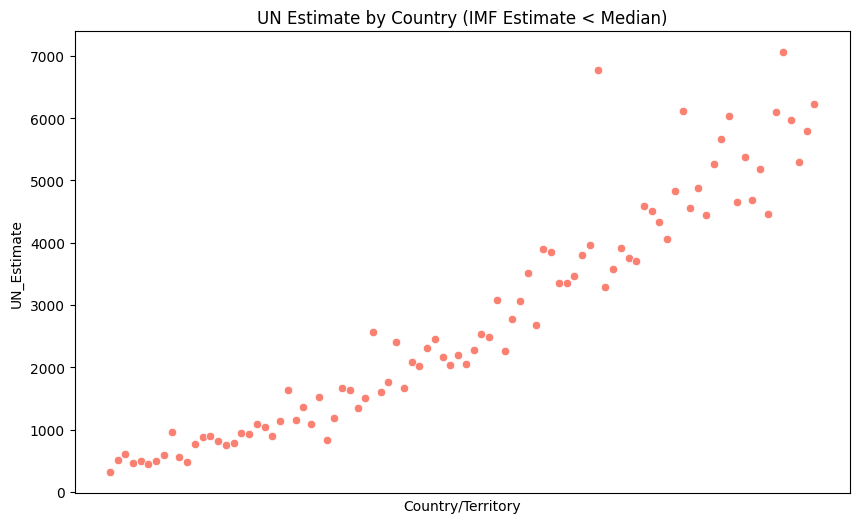

In [31]:
# Scatterplot for countries above median

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered[df_filtered['IMF_Estimate'] < 7058.00].sort_values('IMF_Estimate'),
    x='Country/Territory',
    y='UN_Estimate',
    color = 'salmon'
)

plt.xticks([])
plt.title("UN Estimate by Country (IMF Estimate < Median)")
plt.show()

##3. GDP per Capita by Region




In [32]:
#number of countries by region
df_filtered['UN_Region'].value_counts()

,count
UN_Region,
Africa,52
Europe,41
Asia,41
Americas,35
Oceania,14


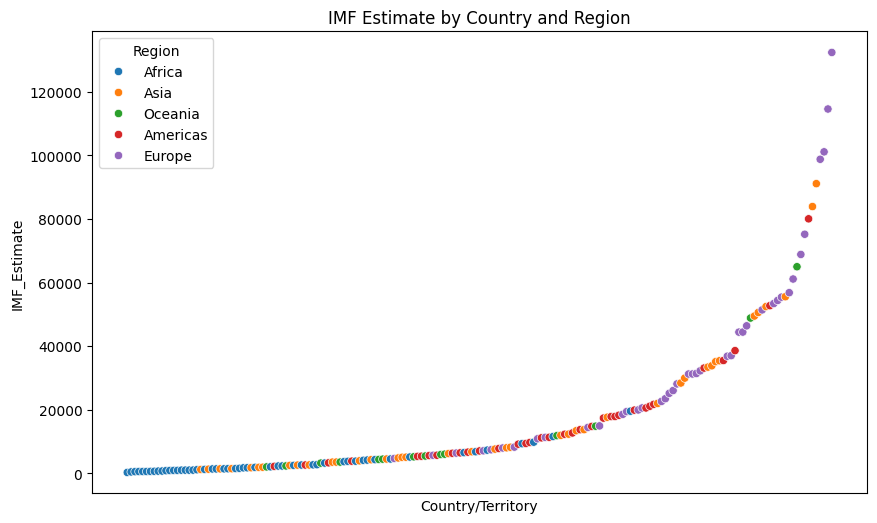

In [33]:
#Scatter plot to show the distribution of countries by region and GDP per capita

df_sorted = df_filtered[df_filtered['UN_Region'] != 'World'].sort_values('IMF_Estimate', ascending=True)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_sorted,
    x='Country/Territory',
    y='IMF_Estimate',
    hue='UN_Region'
)

plt.xticks([])
plt.title("IMF Estimate by Country and Region")
plt.legend(title="Region")

plt.show()

In [34]:
#summary_stats
summary_stats = df_filtered.groupby('UN_Region')['WorldBank_Estimate'].agg(['min', 'max', 'median', 'mean']).round(2)
summary_stats

,min,max,median,mean
UN_Region,,,,
Africa,222,14653,1607.5,2580.38
Americas,1830,70249,9011.0,13752.34
Asia,897,72794,5023.0,16270.32
Europe,4836,133590,26821.0,35662.78
Oceania,1607,60443,4536.5,12131.64


In [35]:
Europe_median = df_filtered[df_filtered['UN_Region'] == 'Europe']['WorldBank_Estimate'].median()
print(f"The median GDP per capita in Europe is {Europe_median} by World Bank")

The median GDP per capita in Europe is 26821.0 by World Bank


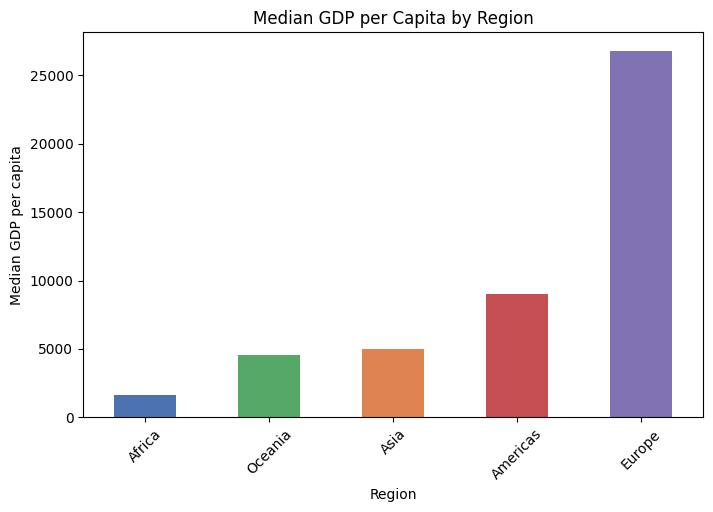

In [36]:
# Bar chart for comparing the medians across regions
regional_medians = (
    df_filtered[df_filtered['UN_Region'] != 'World']
    .groupby('UN_Region')['WorldBank_Estimate']
    .median().sort_values(ascending=True)
)

region_colors = {
    'Africa': '#4C72B0',    # blue
    'Asia': '#DD8452',      # orange
    'Oceania': '#55A868',   # green
    'Americas': '#C44E52',  # red
    'Europe': '#8172B3',    # purple
}

regional_medians.plot(
    kind='bar',
    figsize=(8, 5),
    color=[region_colors[region] for region in regional_medians.index],

)

plt.xlabel('Region')
plt.ylabel('Median GDP per capita')
plt.title('Median GDP per Capita by Region')
plt.xticks(rotation=45)

plt.show()

<Figure size 1000x600 with 0 Axes>

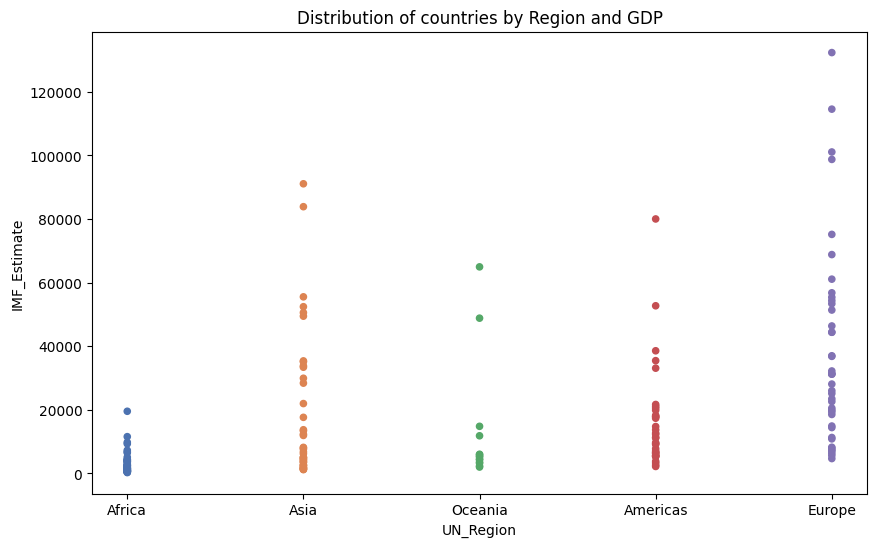

In [37]:
region_colors = {
    'Africa': '#4C72B0',    # blue
    'Asia': '#DD8452',      # orange
    'Oceania': '#55A868',   # green
    'Americas': '#C44E52',  # red
    'Europe': '#8172B3',    # purple
}

df_plot = df_filtered[df_filtered['UN_Region'] != 'World'].sort_values('IMF_Estimate', ascending=True)

plt.figure(figsize=(10,6))
df_plot.plot(x='UN_Region', y='IMF_Estimate', kind='scatter',
        figsize=(10,6),
        title="Distribution of countries by Region and GDP",
        color =[region_colors[region] for region in df_plot['UN_Region']])




plt.show()

##3.1 Zooming in on Europe

In [38]:
#Countries in Europe
df_Europe = df_filtered[df_filtered['UN_Region'] == 'Europe']
df_Europe[['Country/Territory','IMF_Estimate']]

,Country/Territory,IMF_Estimate
3,Luxembourg,132372
4,Ireland,114581
6,Norway,101103
7,Switzerland,98767
13,Iceland,75180
16,Denmark,68827
18,Netherlands,61098
20,Austria,56802
22,Sweden,55395
23,Finland,54351


In [39]:
# Number of countries
print(f"There are {df_Europe['Country/Territory'].count()} countries in Europe")

There are 41 countries in Europe


In [40]:
#Countries in Europe above median by World Bank
df_Europe[df_Europe['WorldBank_Estimate'] > Europe_median][['Country/Territory', 'WorldBank_Estimate']]

,Country/Territory,WorldBank_Estimate
3,Luxembourg,133590
4,Ireland,100172
6,Norway,89154
7,Switzerland,91992
13,Iceland,68728
16,Denmark,68008
18,Netherlands,57768
20,Austria,53638
22,Sweden,61029
23,Finland,53655


In [41]:
#Countries in Europe below median by World Bank
df_Europe[df_Europe['WorldBank_Estimate'] < Europe_median][['Country/Territory', 'WorldBank_Estimate']]



,Country/Territory,WorldBank_Estimate
57,Lithuania,23723
59,Portugal,24568
60,Latvia,21148
62,Slovakia,21392
63,Greece,20193
70,Croatia,17685
72,Poland,18000
75,Hungary,18728
78,Romania,14858
87,Bulgaria,12222


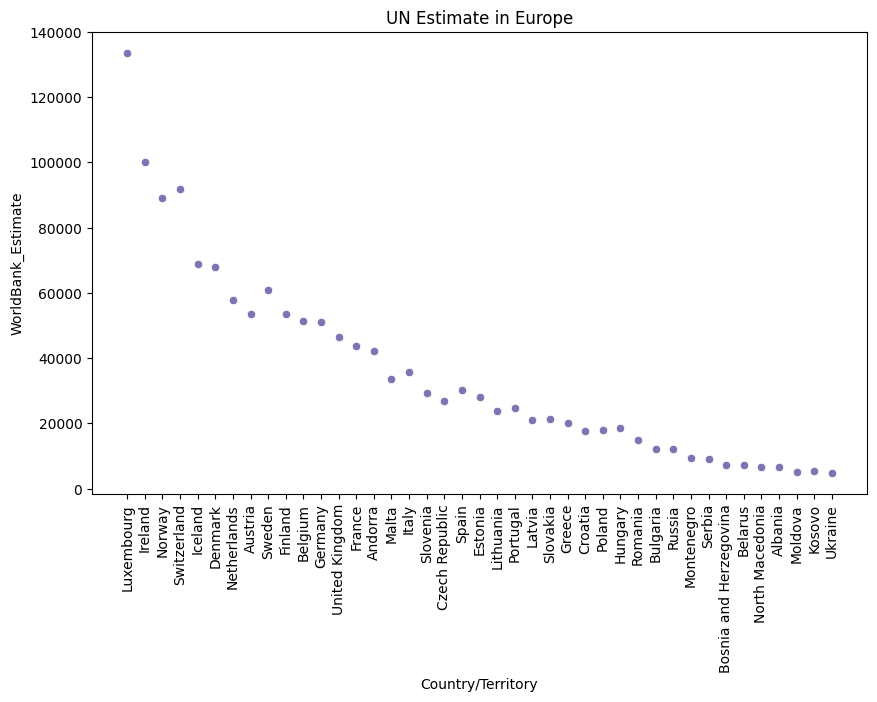

In [42]:
#Countries by GDP per Capita in Europe

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered[df_filtered['UN_Region'] == 'Europe'],
    x='Country/Territory',
    y='WorldBank_Estimate',
    color = '#8172B3'
)
plt.title("UN Estimate in Europe")
plt.xticks(rotation=90)
plt.show()

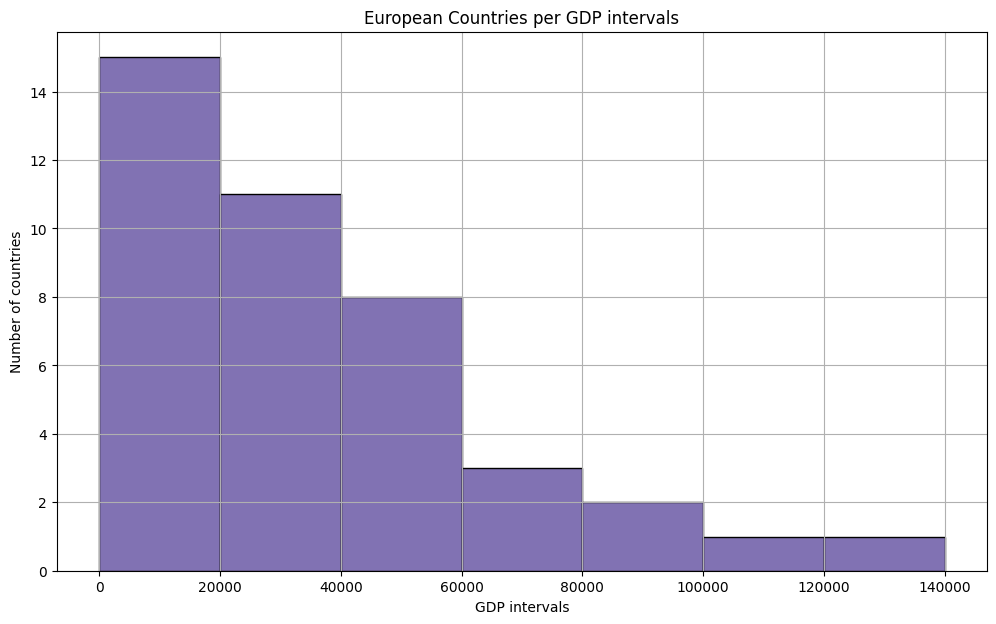

In [43]:
df_Europe['WorldBank_Estimate'].hist(
    bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000],
    figsize=(12, 7),
    color='#8172B3',
    edgecolor='black'
)

plt.xlabel('GDP intervals')
plt.ylabel('Number of countries')
plt.title('European Countries per GDP intervals')

plt.show()

Based on the tables and graphs above, we can see that only a few European countries have a very high GDP per capita. For example, the last graph shows that only four countries have a GDP per capita above $100,000, while most countries are concentrated closer to the European median.

##3.2 UK in Europe

In [44]:
## Which countries in Europe has higher GDP than UK?
uk_gdp = df_Europe[
    df_Europe['Country/Territory'] == 'United Kingdom'
]['IMF_Estimate'].iloc[0]

print(f"UK GDP per capita: {uk_gdp}")

UK GDP per capita: 46371


In [45]:
#European countries with GDP higher than UK
df_Europe[df_Europe['IMF_Estimate'] > uk_gdp][['Country/Territory', 'IMF_Estimate']]

,Country/Territory,IMF_Estimate
3,Luxembourg,132372
4,Ireland,114581
6,Norway,101103
7,Switzerland,98767
13,Iceland,75180
16,Denmark,68827
18,Netherlands,61098
20,Austria,56802
22,Sweden,55395
23,Finland,54351


In [46]:
#European countries with GDP lower than UK
df_Europe[df_Europe['IMF_Estimate'] < uk_gdp][['Country/Territory', 'IMF_Estimate']]


,Country/Territory,IMF_Estimate
34,France,44408
35,Andorra,44387
40,Malta,36989
41,Italy,36812
51,Slovenia,32214
52,Czech Republic,31368
53,Spain,31223
54,Estonia,31209
57,Lithuania,28094
59,Portugal,26012


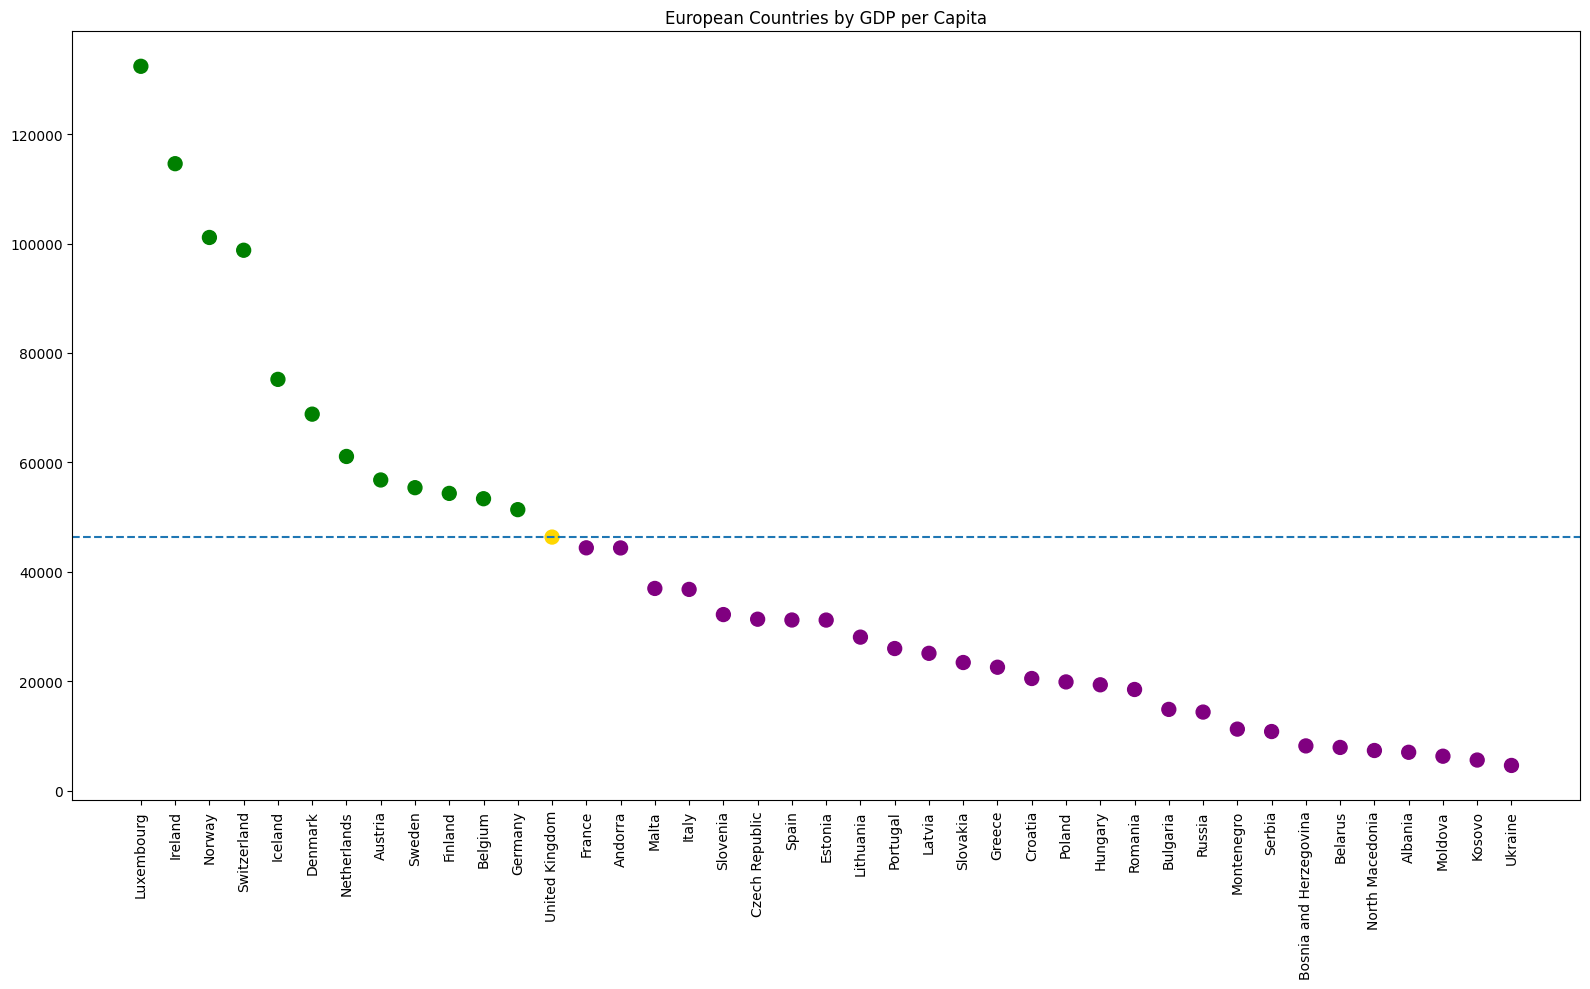

In [47]:
#Scatter Spot with countries below and above UK GDP

uk_gdp = df_Europe[
    df_Europe['Country/Territory'] == 'United Kingdom'
]['IMF_Estimate'].iloc[0]

colors = [
    'gold' if country == 'United Kingdom'
    else 'green' if gdp > uk_gdp
    else 'purple'
    for country, gdp in zip(
        df_Europe['Country/Territory'],
        df_Europe['IMF_Estimate']
    )
]

plt.figure(figsize=(16,10))

plt.scatter(
    df_Europe['Country/Territory'],
    df_Europe['IMF_Estimate'],
    c=colors,
    s=100
)

plt.title('European Countries by GDP per Capita')

plt.axhline(uk_gdp, linestyle='--')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##4 Outliers in Europe

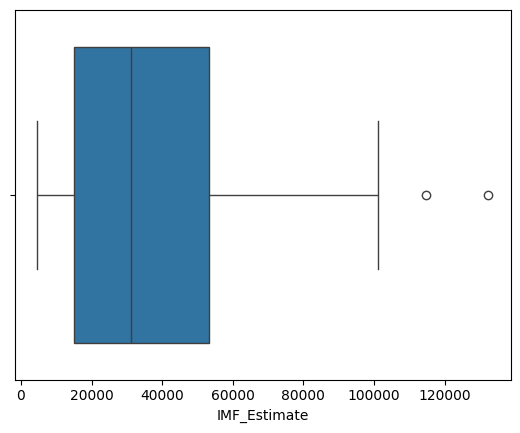

In [48]:
# Boxplot showing the outliers
sns.boxplot(x=df_Europe["IMF_Estimate"])

plt.show()

In [49]:
df_Europe[df_Europe['IMF_Estimate'] > 102000]['Country/Territory']

,Country/Territory
3,Luxembourg
4,Ireland


##5 Global View

In [ ]:
import plotly.express as px

fig = px.choropleth(
    df_filtered,
    locations='Country/Territory',
    locationmode='country names',
    color='IMF_Estimate',
    hover_name='Country/Territory',
    title='World GDP per Capita',
    width=1000, # Adjusting the width of the map
    height=600  # Adjusting the height of the map
)

fig.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Select the GDP per capita values
gdp = df_filtered['WorldBank_Estimate'].dropna()

# Calculate mean and median
mean_gdp = gdp.mean()
median_gdp = gdp.median()

# Create histogram
plt.figure(figsize=(10, 6))

plt.hist(
    gdp,
    bins=25,
    color='#C8B6E2',   # light purple
    edgecolor='white'
)

# Mean line
plt.axvline(
    mean_gdp,
    color='#E6A23C',
    linestyle='--',
    linewidth=2.5,
    label=f'Mean: ${mean_gdp:,.0f}'
)

# Median line
plt.axvline(
    median_gdp,
    color='#4F8A8B',
    linestyle='-',
    linewidth=2.5,
    label=f'Median: ${median_gdp:,.0f}'
)

# Titles and labels
plt.title(
    'Distribution of GDP per Capita',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('GDP per capita (US$)', fontsize=12)
plt.ylabel('Number of countries', fontsize=12)

# Format x-axis as dollars
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()